In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [78]:
df = pd.read_csv("../datasets/household_power.csv", delimiter = ';')
df.head()

/tmp/ipykernel_113569/605946886.py:1: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/household_power.csv", delimiter = ';')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [79]:
cols = df.dtypes[df.dtypes == "object"].index.tolist()
df[cols] = df[cols].apply(pd.to_numeric, errors = "coerce")
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df = df.drop(columns=['Date', 'Time'])
df.dtypes

/tmp/ipykernel_113569/4207162104.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
datetime                 datetime64[us]
dtype: object

In [80]:
df["hour"] = df["datetime"].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['dayofweek'] = df['datetime'].dt.day_of_week

In [81]:
df['total_meter'] = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']

In [82]:
df = df.dropna()

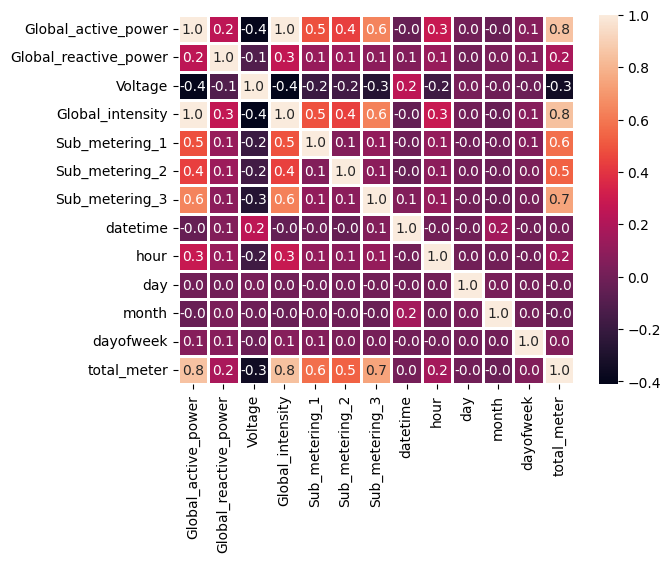

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = df.corr()
sns.heatmap(corr, annot = True, fmt = '.1f', linewidths=2)
plt.show()

In [84]:
df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'datetime', 'hour', 'day', 'month', 'dayofweek',
       'total_meter'],
      dtype='str')

In [85]:
keep_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'total_meter',]
discard_cols = ['Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'hour', 'day', 'month', 'dayofweek', 'datetime']

df = df.drop(columns=discard_cols)
df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'total_meter'],
      dtype='str')

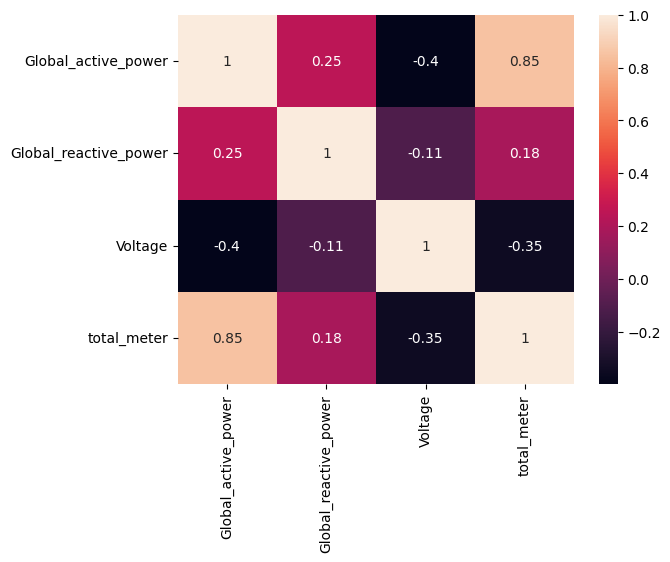

In [86]:
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [87]:
X = df.drop(columns=['Global_active_power'])
y = df['Global_active_power']

In [88]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [89]:
df.dtypes

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
total_meter              float64
dtype: object

In [90]:
lr = LinearRegression()

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

In [91]:
stack = StackingRegressor(
    estimators=[
        ("lr", lr),
        ("xgb", xgb)
    ],
    final_estimator=LinearRegression()
)

In [92]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", stack)
])

In [93]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lr', ...), ('xgb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",LinearRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final

In [94]:
pred = pipeline.predict(X_test)

print("R2:", r2_score(y_test, pred))

R2: 0.81459015374535
